In [59]:
import os
import re
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from tbparse import SummaryReader
from tueplots import bundles
from tueplots.constants.color import palettes

# Keep plotting style consistent with existing slides
plt.rcParams.update(bundles.beamer_moml())
plt.rcParams.update({'font.sans-serif': 'DejaVu Sans', 'figure.dpi': 200})

# change directory to project root
os.chdir(os.path.expanduser("~/Desktop/pomdp_coder"))
print(os.getcwd())
base_dir = os.path.join("outputs")

C:\Users\Frederik\Desktop\pomdp_coder


In [10]:
def load_avg_reward_df(path: str):
    """Return the Average Episode Reward scalars for a given experiment directory."""
    reader = SummaryReader(path, extra_columns={'dir_name'})
    df = reader.scalars
    return df[df['tag'] == "Episode Reward"].reset_index(drop=True)
    # return df[df['tag'] == "Average Episode Reward"].reset_index(drop=True)

def get_clean_df_exp2(path: str):
    """Return a cleaned DataFrame with only relevant columns."""
    df = load_avg_reward_df(path)
    df['seed'] = df['dir_name'].apply(lambda x: re.search(r"_seed(\d+)", x).group(1))
    df['model'] = df['dir_name'].apply(lambda x: re.search(r"_model(\w+)_attempts", x).group(1))
    df['episode'] = df['step'] 
    df = df.drop(columns=['tag', 'step', 'dir_name'])
    df = df[['model', 'seed', 'episode', 'value']]
    return df

In [11]:
path = os.path.join(base_dir, "rocksample", "ours", "2025-12-04")
df = get_clean_df_exp2(path)
df.head()

,model,seed,episode,value
0,qwen3,0,0,7.740063
1,qwen3,0,1,16.790119
2,qwen3,0,2,14.526272
3,qwen3,0,3,11.969052
4,qwen3,0,4,15.802727


In [12]:
df_qwen2 = pd.read_csv(os.path.join(base_dir, "process_outputs", "baseline_results.csv"))
df_qwen2 = df_qwen2[(df_qwen2['approach'] == "ours") & (df_qwen2['environment'] == "rocksample")]
df_qwen2 = df_qwen2.drop(columns=['environment', 'approach'])
df_qwen2["model"] = "qwen2"
df_qwen2 = df_qwen2[['model', 'seed', 'episode', 'value']]
df_qwen2.head()

,model,seed,episode,value
500,qwen2,0,0,7.936056
501,qwen2,0,1,4.348660
502,qwen2,0,2,-8.017041
503,qwen2,0,3,-10.266643
504,qwen2,0,4,-5.024959


In [13]:
df = pd.concat([df_qwen2, df], ignore_index=True)

In [14]:
df_avg = df.groupby('model')['value'].agg(['mean', 'sem']).reset_index()
df_avg = df_avg.sort_values('model')
df_avg

,model,mean,sem
0,qwen2,2.699009,0.867762
1,qwen3,12.456616,0.531505


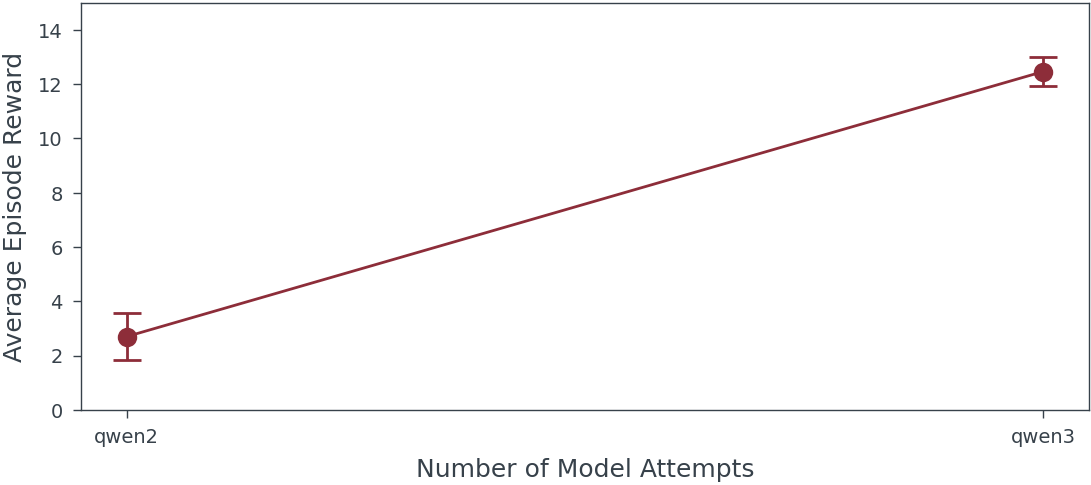

In [17]:
fig, ax = plt.subplots()
ax.errorbar(df_avg["model"], df_avg['mean'], yerr=df_avg['sem'], 
            marker='o', capsize=5, label='Average Reward')
ax.set_xlabel('Number of Model Attempts')
ax.set_xticks(df_avg["model"]) 
ax.set_ylabel('Average Episode Reward')
ax.set_ylim(0, 15)
plt.show()

In [19]:
df_rs = pd.read_csv(os.path.join(base_dir, "process_outputs", "baseline_results.csv"))
df_rs = df_rs[df_rs['environment'] == "rocksample"]
df_rs

,environment,approach,seed,episode,value
400,rocksample,hardcoded,0,0,7.898024
401,rocksample,hardcoded,0,1,6.074036
402,rocksample,hardcoded,0,2,15.278893
403,rocksample,hardcoded,0,3,14.842326
404,rocksample,hardcoded,0,4,23.459429
...,...,...,...,...,...
795,rocksample,random,9,5,-6.068998
796,rocksample,random,9,6,-0.666905
797,rocksample,random,9,7,8.039208
798,rocksample,random,9,8,0.626234


In [30]:
df_rs_qwen3 = df[df['model'] == "qwen3"].copy()
df_rs_qwen3['environment'] = "rocksample"
df_rs_qwen3['approach'] = "ours_qwen3"
df_rs_qwen3 = df_rs_qwen3.drop(columns=['model'])
df_rs_qwen3 = df_rs_qwen3[['environment', 'approach', 'seed', 'episode', 'value']]
df_rs = pd.concat([df_rs, df_rs_qwen3], ignore_index=True)
df_rs

,environment,approach,seed,episode,value
0,rocksample,hardcoded,0,0,7.898024
1,rocksample,hardcoded,0,1,6.074036
2,rocksample,hardcoded,0,2,15.278893
3,rocksample,hardcoded,0,3,14.842326
4,rocksample,hardcoded,0,4,23.459429
...,...,...,...,...,...
595,rocksample,ours_qwen3,9,5,16.858801
596,rocksample,ours_qwen3,9,6,-9.992836
597,rocksample,ours_qwen3,9,7,12.469545
598,rocksample,ours_qwen3,9,8,12.757716


In [36]:
# get the normalized values per environment and use that for plotting
df_normalized = df_rs.groupby(['environment', 'approach'])['value'].mean().reset_index()

# Get the hardcoded mean per environment
hardcoded_means = (
    df_normalized[df_normalized['approach'] == 'hardcoded']
    .set_index('environment')['value']        # Series: env -> mean(hardcoded)
)

df_plot = df_rs.groupby(['environment', 'approach'])['value'].agg(['mean', 'sem']).reset_index()
df_plot['mean_norm'] = df_plot['mean'] / df_plot['environment'].map(hardcoded_means)
df_plot['sem_norm'] = df_plot['sem'] / df_plot['environment'].map(hardcoded_means)
df_plot

,environment,approach,mean,sem,mean_norm,sem_norm
0,rocksample,hardcoded,12.741056,0.537741,1.000000,0.042205
1,rocksample,ours,2.699009,0.867762,0.211836,0.068108
2,rocksample,ours_qwen3,12.456616,0.374885,0.977675,0.029423
3,rocksample,random,-3.461351,0.971523,-0.271669,0.076251
4,rocksample,tabular,5.769145,0.691104,0.452800,0.054242


In [ ]:
approaches = ["hardcoded", "ours", "tabular", "random", "ours_qwen3"]
df_plot["approach"] = pd.Categorical(df_plot["approach"], categories=approaches, ordered=True)
df_plot = df_plot.sort_values(["approach"])
df_plot

,environment,approach,mean,sem,mean_norm,sem_norm
0,rocksample,hardcoded,12.741056,0.537741,1.000000,0.042205
1,rocksample,ours,2.699009,0.867762,0.211836,0.068108
4,rocksample,tabular,5.769145,0.691104,0.452800,0.054242
3,rocksample,random,-3.461351,0.971523,-0.271669,0.076251
2,rocksample,ours_qwen3,12.456616,0.374885,0.977675,0.029423


(0.0, 1.1)

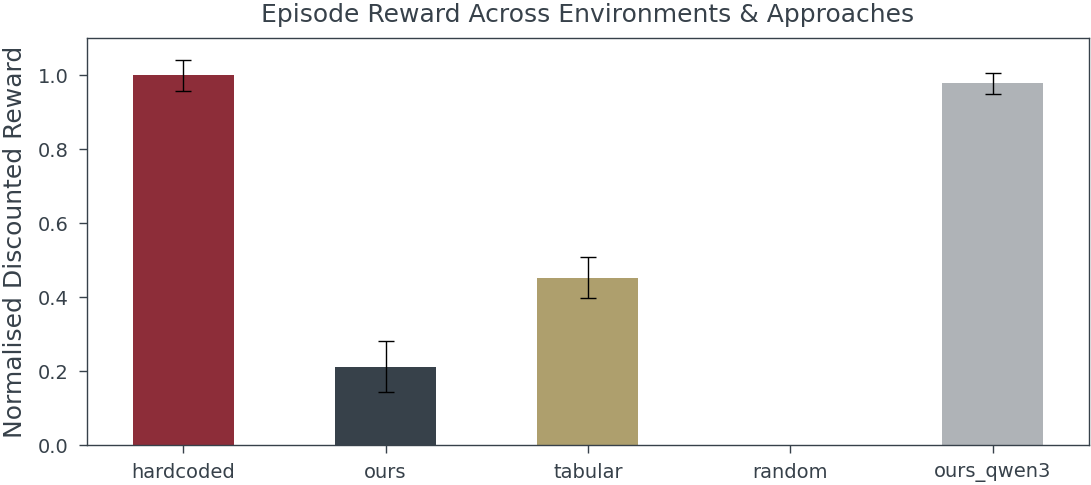

In [61]:
x = np.arange(len(approaches))
width = 0.5                       # bar width (tune for #approaches)

fig, ax = plt.subplots()

means = df_plot["mean_norm"].values
stds = df_plot["sem_norm"].values

ax.bar(
    x,
    means,
    width,
    yerr=stds,
    color=palettes.tue_plot,
    capsize=3,
    error_kw=dict(linewidth=0.5, capthick=0.5),
)

ax.set_xticks(x)
ax.set_xticklabels(approaches)
ax.set_ylabel("Normalised Discounted Reward")
ax.set_title("Episode Reward Across Environments & Approaches")
ax.set_ylim(0, 1.1)